In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns


In [3]:
fst_mat = pd.read_csv("101_Fst_populations.csv", index_col= 0 )
fst_mat.iloc[:5,:5]

,Albania,Brasil,Bulgaria,Cameroon,ChristmasIsland
Albania,0.0000,0.1202,0.0617,0.0745,0.1101
Brasil,0.1202,0.0000,0.1053,0.0735,0.1024
Bulgaria,0.0617,0.1053,0.0000,0.0507,0.0846
Cameroon,0.0745,0.0735,0.0507,0.0000,0.0549
ChristmasIsland,0.1101,0.1024,0.0846,0.0549,0.0000


In [8]:
(fst_mat < 0 ).sum().sum()

58

Som values are < 0, in particular Liechtenstein and Thailand.

We will drop them

In [10]:
D = fst_mat.drop(index =  ['Thailand',"Liechtenstein"] ,
                 columns= ['Thailand',"Liechtenstein"] 
                )
D[D<0] = 0

(D < 0 ).sum().sum()

0

We will use a heatmap,

I just need to hack a bit the metric function of clustermap so that it takes the values in the matrix itself

/home/wandrille/Installed_software/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/wandrille/Installed_software/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


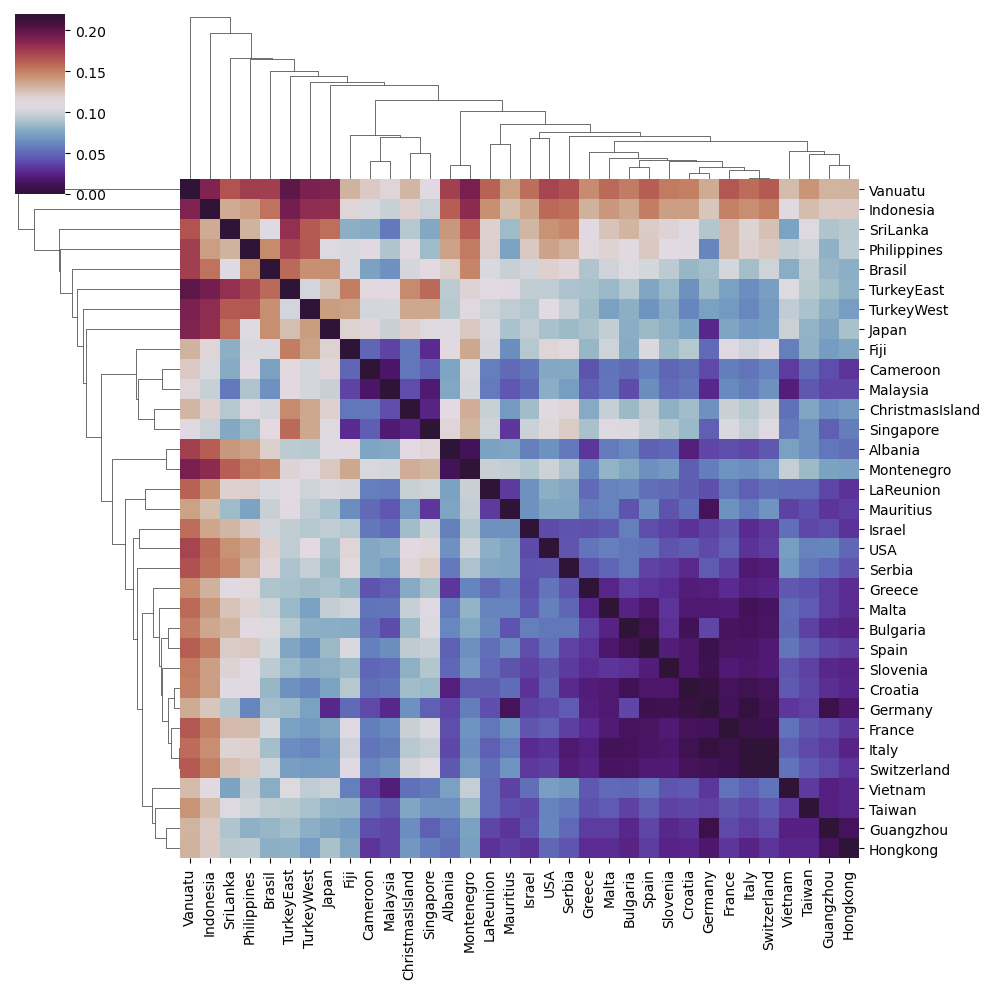

In [24]:

def firstZero(x):
    '''find the first 0 in the given list'''
    return list( x==0 ).index(True)
def tmp(a,b):
    '''a and b are 2 rows in a distance matrix
        we use the position of 0s in these row to identify where we are in the matrix
        and return the corresponding distance
    '''
    j=firstZero(b)
    return a[j]


g = sns.clustermap( D , method = 'average' , z_score= None , metric = tmp , 
               cmap = "twilight_shifted", vmin = 0 , vmax = 0.22)
g.savefig("102_Fst_populations.pdf")

---

/home/wandrille/Installed_software/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/wandrille/Installed_software/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


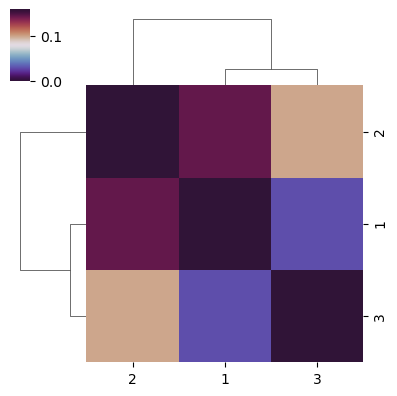

In [26]:
fst_mat = pd.read_csv("101_Fst_DAPC_all.3clusters.csv", index_col= 0 )
sns.clustermap( fst_mat , z_score= None , metric = tmp , figsize=(4,4) , 
               vmin = 0 , vmax = 0.16, cmap = "twilight_shifted")

/home/wandrille/Installed_software/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/wandrille/Installed_software/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


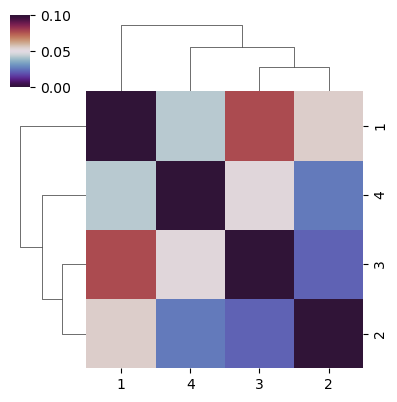

In [30]:
fst_mat = pd.read_csv("101_Fst_DAPC_noIndonesia.4clusters.csv", index_col= 0 )
sns.clustermap( fst_mat , z_score= None , metric = tmp , figsize=(4,4),
              vmin = 0 , vmax = 0.1, cmap = "twilight_shifted")

In [38]:

dapc3 = pd.read_csv("071_DAPC_all.3clusters.csv", index_col=0)
sampleId_to_dapc3 = dapc3[['1','2','3']].idxmax(axis = 1).to_dict()

In [41]:
dapc4 = pd.read_csv("071_DAPC_noIndonesia.4clusters.csv", index_col=0)
sampleId_to_dapc4 = dapc4[['1','2','3','4']].idxmax(axis = 1).to_dict()

In [43]:
pop_info_file = "albo_global_pops_UNSD.txt"

pop_table = pd.read_table(pop_info_file,sep='\t', header=None )
pop_table.columns = ['indv','pop','native_invasive']
pop_table.index = pop_table.indv + '_' + pop_table.indv
pop_table.head()

,indv,pop,native_invasive
indv,,,
ALKR1_ALKR1,ALKR1,Albania,invaded
ALKR3_ALKR3,ALKR3,Albania,invaded
ALKR4_ALKR4,ALKR4,Albania,invaded
ALKR5_ALKR5,ALKR5,Albania,invaded
ALSH2_ALSH2,ALSH2,Albania,invaded


In [46]:
pop_table['dapc3'] = [sampleId_to_dapc3.get(i,-1) for i in pop_table.index]
pop_table['dapc4'] = [sampleId_to_dapc4.get(i,-1) for i in pop_table.index]

In [47]:
pd.crosstab( pop_table.dapc3 , pop_table.dapc4 )

dapc4,-1,1,2,3,4
dapc3,,,,,
-1,152,0,0,0,0
1,0,0,0,192,0
2,45,0,0,0,0
3,0,18,88,0,74


In [52]:
pop_table = pop_table.loc[ pop_table.dapc3 != -1 , : ]
pd.crosstab( pop_table['pop'] , pop_table.dapc4 )

dapc4,-1,1,2,3,4
pop,,,,,
Albania,0,0,0,6,0
Brasil,0,8,0,0,0
Bulgaria,0,0,0,3,0
Cameroon,0,0,0,0,8
ChristmasIsland,0,0,0,0,4
Croatia,0,1,0,9,0
Fiji,0,0,0,0,5
France,0,0,0,17,0
Germany,0,0,0,2,0


In [82]:
country_to_cls = {}
for country in pop_table['pop'].unique():
    cls = pop_table.dapc4[ pop_table['pop'] == country ].unique()
    if len(cls) == 1 : 
        country_to_cls[country] = str( cls[0] )
    else:
        print(f"{country} -> ", list(cls))
        country_to_cls[country] = 'mixed'

Croatia ->  ['1', '3']
Greece ->  ['2', '3']
Italy ->  ['3', '1']
Vietnam ->  ['2', '4']


In [83]:
country_to_cls.values()

dict_values(['3', '1', '3', '4', '4', 'mixed', '4', '3', '3', 'mixed', '2', '2', '3', 'mixed', '3', '2', '3', '3', '2', '3', '3', '3', '3', '4', '3', '2', '3', '3', '3', '1', '-1', '4', '2', '4', '4', 'mixed'])

In [90]:
# cl_to_color = { '1' : (27,158,119),
#                 '2' : (217,95,2),
#                 '3' : (117,112,179),
#                 '4' : (231,41,138),
#                 'mixed' : (180,180,180),
#                 '-1' : (16,16,16)}
cl_to_color = { '1' : 'orange',
                '2' : 'teal',
                '3' : 'lightcoral',
                '4' : 'chartreuse',
                'mixed' : 'lightgrey',
                '-1' : 'dimgrey'}


In [91]:
row_colors = list( D.index.map( country_to_cls ).map( cl_to_color )  )

/home/wandrille/Installed_software/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/home/wandrille/Installed_software/anaconda3/envs/py311/lib/python3.11/site-packages/seaborn/matrix.py:530: ClusterWarning: scipy.cluster: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


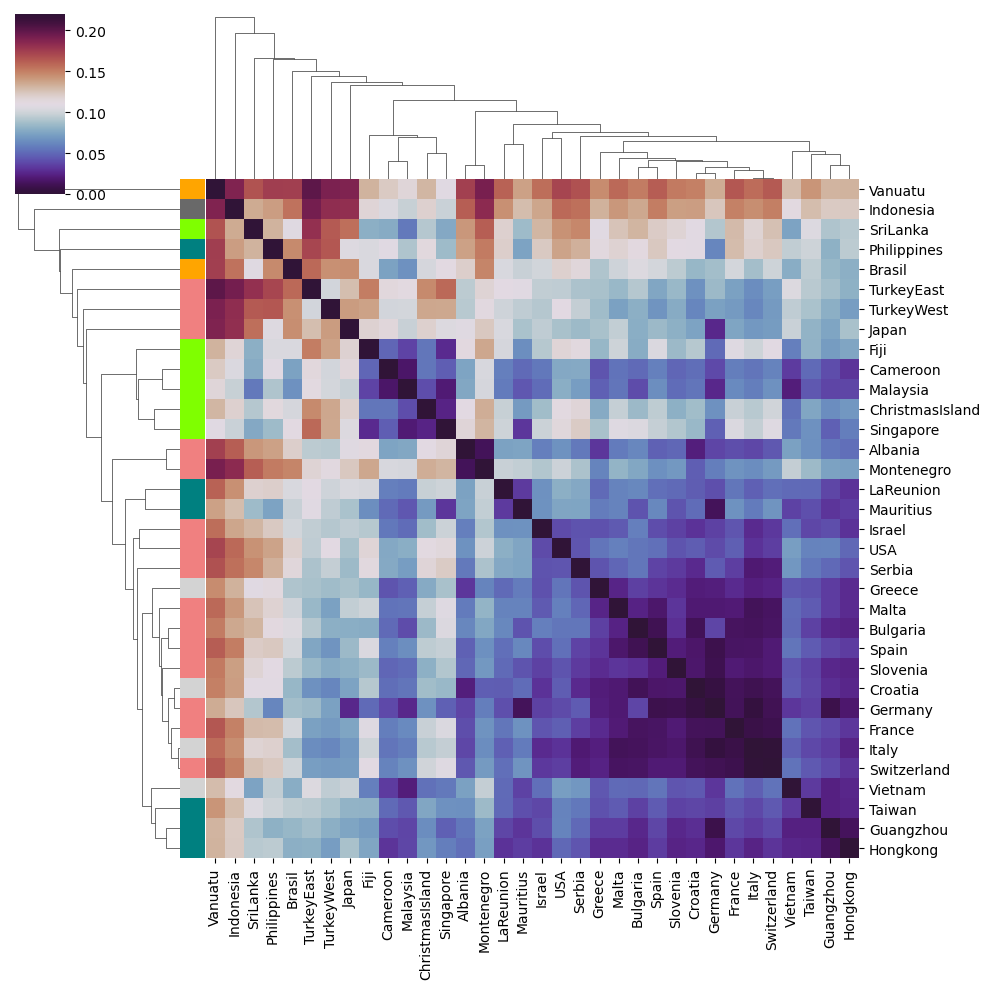

In [94]:
g = sns.clustermap( D , method = 'average' , z_score= None , metric = tmp , 
               cmap = "twilight_shifted", vmin = 0 , vmax = 0.22,
                  row_colors= row_colors)
g.savefig("102_Fst_populations.dapc_cluster_color.pdf")